# Gradient-Based Poisoning em VQR

Este notebook implementa um ataque de poisoning para regressao quantica (VQR).
A ideia do laco externo e mover amostras envenenadas para maximizar o erro de validacao do modelo treinado com esses pontos.

Requer **pandas** (por exemplo `%pip install -q pandas`) para carregar `data/world-data-2023.csv`.

## 1) Imports e configuracao

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter, ParameterVector
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.algorithms.regressors import VQR

np.random.seed(7)

## 2) Dataset real (`data/world-data-2023.csv`)

Alvo: **CPI**. Entrada do VQR: **GDP** normalizada para \([-\pi, \pi]\). Mesma divisao treino/validacao/teste que no fluxo original (`random_state=7`).

In [14]:
FEATURE_COL = "GDP"

def _world_csv_path():
    root = Path.cwd()
    for p in (
        root / "data" / "world-data-2023.csv",
        root.parent / "data" / "world-data-2023.csv",
        root / "world-data-2023.csv",
    ):
        if p.is_file():
            return p.resolve()
    raise FileNotFoundError(
        "Coloque world-data-2023.csv em ./data/ na raiz do repositorio."
    )


def _clean_num(series):
    s = series.astype(str).str.replace(",", "", regex=False)
    s = s.str.replace("%", "", regex=False)
    s = s.str.replace("$", "", regex=False)
    s = s.str.strip()
    s = s.replace({"": np.nan, "nan": np.nan, "None": np.nan})
    return pd.to_numeric(s, errors="coerce")


_csv_path = _world_csv_path()
_df = pd.read_csv(_csv_path)
_df["CPI"] = _clean_num(_df["CPI"])
_df[FEATURE_COL] = _clean_num(_df[FEATURE_COL])
_df = _df.dropna(subset=["CPI", FEATURE_COL])

X_raw = _df[FEATURE_COL].to_numpy(dtype=float).reshape(-1, 1)
y_raw = _df["CPI"].to_numpy(dtype=float)

y_min, y_max = float(y_raw.min()), float(y_raw.max())
if y_max - y_min < 1e-12:
    raise ValueError("Sem variancia em CPI")

y = (y_raw - y_min) / (y_max - y_min) * 2.0 - 1.0

_x0, _x1 = float(X_raw.min()), float(X_raw.max())
if _x1 - _x0 < 1e-12:
    raise ValueError(f"Sem variancia na coluna {FEATURE_COL}")
X = (X_raw - _x0) / (_x1 - _x0) * (2 * np.pi) - np.pi

X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=7,
)

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train_raw,
    y_train_raw,
    test_size=0.3,
    random_state=7,
)

x_min, x_max = float(X.min()), float(X.max())
print(
    f"Arquivo: {_csv_path.name} | alvo=CPI | feature={FEATURE_COL} | "
    f"Shapes: {X_fit.shape} {X_val.shape} {X_test.shape}"
)

Arquivo: world-data-2023.csv | alvo=CPI | feature=GDP | Shapes: (93, 1) (40, 1) (45, 1)


## 3) Treino do modelo limpo (baseline)

In [15]:
def build_vqr(maxiter=60):
    x_param = Parameter('x')
    theta = ParameterVector('theta', 4)

    feature_map = QuantumCircuit(2, name='feature_map')
    feature_map.ry(x_param, 0)
    feature_map.ry(x_param, 1)

    ansatz = QuantumCircuit(2, name='ansatz')
    ansatz.ry(theta[0], 0)
    ansatz.ry(theta[1], 1)
    ansatz.cx(0, 1)
    ansatz.ry(theta[2], 0)
    ansatz.ry(theta[3], 1)

    estimator = StatevectorEstimator()
    optimizer = COBYLA(maxiter=maxiter)

    return VQR(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer,
        estimator=estimator,
    )


def train_vqr(X_train_local, y_train_local, maxiter=60):
    model = build_vqr(maxiter=maxiter)
    model.fit(X_train_local, y_train_local)
    return model


def mse_on_dataset(model, X_eval, y_eval):
    pred = np.asarray(model.predict(X_eval))
    return float(mean_squared_error(y_eval, pred))


clean_model = train_vqr(X_fit, y_fit, maxiter=60)
clean_val_mse = mse_on_dataset(clean_model, X_val, y_val)
clean_test_mse = mse_on_dataset(clean_model, X_test, y_test)

print(f'Clean validation MSE: {clean_val_mse:.4f}')
print(f'Clean test MSE:       {clean_test_mse:.4f}')


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Clean validation MSE: 0.1194
Clean test MSE:       0.0307


## 4) Ataque gradient-based poisoning

In [16]:
poison_count = 4
outer_steps = 8
finite_diff_eps = 0.12
poison_lr = 0.40
# target_value on the normalized CPI scale [-1, 1]
target_value = 0.90

rng = np.random.default_rng(7)
poison_indices = rng.choice(len(X_fit), size=poison_count, replace=False)

X_base = np.delete(X_fit, poison_indices, axis=0)
y_base = np.delete(y_fit, poison_indices, axis=0)
X_poison = X_fit[poison_indices].copy()
y_poison = np.full(poison_count, target_value, dtype=float)

print('Poison indices:', poison_indices)
print('Initial poison points:')
print(X_poison)


def poisoned_dataset(X_poison_candidate):
    X_train_poisoned = np.vstack([X_base, X_poison_candidate])
    y_train_poisoned = np.concatenate([y_base, y_poison])
    return X_train_poisoned, y_train_poisoned


def attack_objective(X_poison_candidate):
    X_train_poisoned, y_train_poisoned = poisoned_dataset(X_poison_candidate)
    model = train_vqr(X_train_poisoned, y_train_poisoned, maxiter=35)
    return mse_on_dataset(model, X_val, y_val), model


def finite_difference_gradient(X_poison_candidate):
    gradient = np.zeros_like(X_poison_candidate)
    base_mse, _ = attack_objective(X_poison_candidate)
    for row in range(X_poison_candidate.shape[0]):
        plus = X_poison_candidate.copy()
        minus = X_poison_candidate.copy()
        plus[row, 0] = np.clip(plus[row, 0] + finite_diff_eps, x_min, x_max)
        minus[row, 0] = np.clip(minus[row, 0] - finite_diff_eps, x_min, x_max)
        mse_plus, _ = attack_objective(plus)
        mse_minus, _ = attack_objective(minus)
        gradient[row, 0] = (mse_plus - mse_minus) / (2.0 * finite_diff_eps)
    return base_mse, gradient


history = []
for step in range(outer_steps):
    mse_value, gradient = finite_difference_gradient(X_poison)
    X_poison = np.clip(X_poison + poison_lr * gradient, x_min, x_max)
    poisoned_val_mse_step, _ = attack_objective(X_poison)
    history.append((step + 1, poisoned_val_mse_step, np.linalg.norm(gradient)))
    print(
        f'Step {step + 1}: validation MSE = {poisoned_val_mse_step:.4f}, '
        f'gradient norm = {np.linalg.norm(gradient):.4f}'
    )

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Poison indices: [85 56 83 62]
Initial poison points:
[[-3.09444935]
 [-3.13727059]
 [-3.08011463]
 [-3.13758766]]


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. I

Step 1: validation MSE = 0.1130, gradient norm = 0.0801


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. I

...

Step 6: validation MSE = 0.1224, gradient norm = 0.0806


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. I

Step 7: validation MSE = 0.1169, gradient norm = 0.1062


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. I

Step 8: validation MSE = 0.1119, gradient norm = 0.0342


## 5) Avaliacao do modelo contaminado

Além do conjunto de teste original, acrescentamos **pontos-probe** nas coordenadas $x$ onde o ataque otimizou os venenos (mais uma grade local nesse intervalo). Esses probes são usados como diagnóstico: o rótulo de referência é a predicação do **VQR limpo** nesses $x$, não um valor CPI real.

- O MSE nos probes mede o desvio induzido pelo modelo envenenado em relação à superfície benigna do modelo limpo.
- O ASR proxy nos probes avalia a fração de predições do modelo envenenado que se aproximam do valor de ataque `target_value`.
- O teste estendido combina o conjunto de teste original com esses probes para exibir o impacto do ataque em uma avaliação mais sensível.

Dessa forma, garantimos métricas mais significativas e alinhadas com a região onde o ataque realmente atuou.

In [17]:
final_poisoned_X, final_poisoned_y = poisoned_dataset(X_poison)
poisoned_model = train_vqr(final_poisoned_X, final_poisoned_y, maxiter=60)

poisoned_val_mse = mse_on_dataset(poisoned_model, X_val, y_val)
poisoned_test_mse = mse_on_dataset(poisoned_model, X_test, y_test)

pred_clean_test = np.asarray(clean_model.predict(X_test))
pred_poisoned_test = np.asarray(poisoned_model.predict(X_test))

tol = 0.18
asr_clean = np.mean(np.abs(pred_clean_test - target_value) <= tol)
asr_poisoned = np.mean(np.abs(pred_poisoned_test - target_value) <= tol)

print(f'Poisoned validation MSE: {poisoned_val_mse:.4f}')
print(f'Poisoned test MSE:       {poisoned_test_mse:.4f}')
print(f'Test MSE increase:       {poisoned_test_mse - clean_test_mse:.4f}')
print(f'ASR proxy clean:         {asr_clean:.4f}')
print(f'ASR proxy poisoned:      {asr_poisoned:.4f}')

# Pontos extras no teste: regiao onde o gradiente moveu os venenos (ativa o efeito do ataque).
# y_ref = predicao do VQR limpo nesses x (superficie benigna); MSE do envenenado mede desvio induzido.
_x_lo, _x_hi = float(X_poison[:, 0].min()), float(X_poison[:, 0].max())
_x_grid = np.linspace(_x_lo, _x_hi, num=12).reshape(-1, 1)
X_test_probe = np.vstack([X_poison, _x_grid])
y_test_probe_ref = np.asarray(clean_model.predict(X_test_probe)).ravel()

pred_clean_probe = np.asarray(clean_model.predict(X_test_probe))
pred_poisoned_probe = np.asarray(poisoned_model.predict(X_test_probe))
mse_clean_probe = float(mean_squared_error(y_test_probe_ref, pred_clean_probe))
mse_poisoned_probe = float(mean_squared_error(y_test_probe_ref, pred_poisoned_probe))
asr_poisoned_probe = float(np.mean(np.abs(pred_poisoned_probe - target_value) <= tol))

X_test_extended = np.vstack([X_test, X_test_probe])
y_test_extended = np.concatenate([y_test, y_test_probe_ref])
clean_ext_mse = mse_on_dataset(clean_model, X_test_extended, y_test_extended)
poisoned_ext_mse = mse_on_dataset(poisoned_model, X_test_extended, y_test_extended)

print()
print('--- Teste + probes na regiao do veneno (y_ref = VQR limpo nesses x) ---')
print(f'Probes adicionados ao teste: {X_test_probe.shape[0]}')
print(f'MSE apenas nos probes | limpo:       {mse_clean_probe:.4f}')
print(f'MSE apenas nos probes | envenenado: {mse_poisoned_probe:.4f}')
print(f'Desvio MSE (probes):                 {mse_poisoned_probe - mse_clean_probe:.4f}')
print(f'ASR proxy poisoned (probes):         {asr_poisoned_probe:.4f}')
print(f'Teste estendido MSE | limpo:         {clean_ext_mse:.4f}')
print(f'Teste estendido MSE | envenenado:   {poisoned_ext_mse:.4f}')

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Poisoned validation MSE: 0.1110
Poisoned test MSE:       0.0371
Test MSE increase:       0.0064
ASR proxy clean:         0.0000
ASR proxy poisoned:      0.0000

--- Teste + probes na regiao do veneno (y_ref = VQR limpo nesses x) ---
Probes adicionados ao teste: 16
MSE apenas nos probes | limpo:       0.0006
MSE apenas nos probes | envenenado: 0.0085
Desvio MSE (probes):                 0.0079
ASR proxy poisoned (probes):         0.0000
Teste estendido MSE | limpo:         0.0240
Teste estendido MSE | envenenado:   0.0297


## 6) Visualizacoes e interpretacao

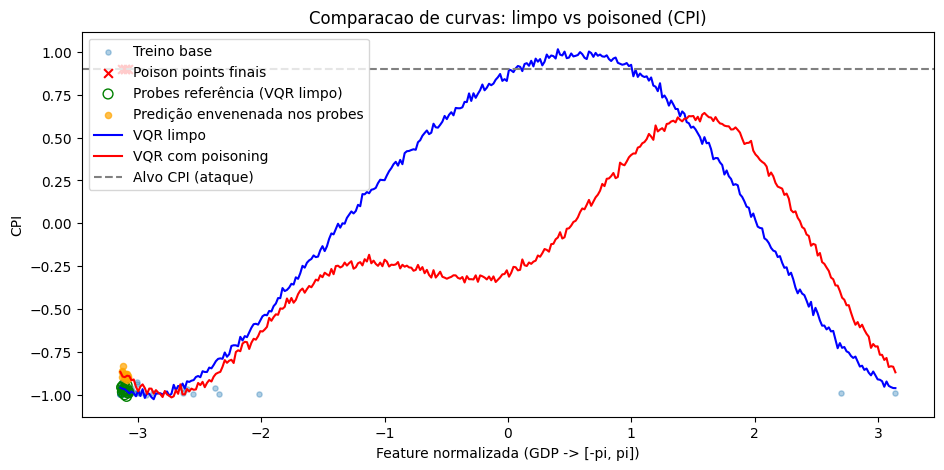

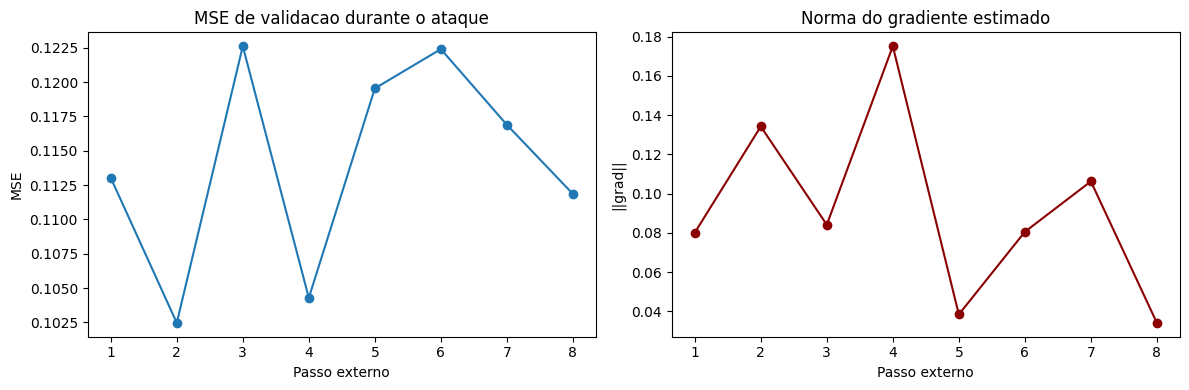

In [18]:
X_plot = np.linspace(x_min, x_max, 350).reshape(-1, 1)
y_plot_clean = np.asarray(clean_model.predict(X_plot))
y_plot_poisoned = np.asarray(poisoned_model.predict(X_plot))

plt.figure(figsize=(11, 5))
plt.scatter(X_fit[:, 0], y_fit, s=14, alpha=0.35, label='Treino base')
plt.scatter(X_poison[:, 0], y_poison, s=40, marker='x', color='red', label='Poison points finais')
plt.scatter(X_test_probe[:, 0], y_test_probe_ref, s=50, facecolors='none', edgecolors='green', label='Probes referência (VQR limpo)')
plt.scatter(X_test_probe[:, 0], pred_poisoned_probe, s=20, color='orange', alpha=0.7, label='Predição envenenada nos probes')
plt.plot(X_plot[:, 0], y_plot_clean, 'b', label='VQR limpo')
plt.plot(X_plot[:, 0], y_plot_poisoned, 'r', label='VQR com poisoning')
plt.axhline(target_value, color='gray', linestyle='--', label='Alvo CPI (ataque)')
plt.title('Comparacao de curvas: limpo vs poisoned (CPI)')
plt.xlabel('Feature normalizada (GDP -> [-pi, pi])')
plt.ylabel('CPI')
plt.legend()
plt.show()

if history:
    steps, mses, norms = zip(*history)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(steps, mses, marker='o')
    ax[0].set_title('MSE de validacao durante o ataque')
    ax[0].set_xlabel('Passo externo')
    ax[0].set_ylabel('MSE')

    ax[1].plot(steps, norms, marker='o', color='darkred')
    ax[1].set_title('Norma do gradiente estimado')
    ax[1].set_xlabel('Passo externo')
    ax[1].set_ylabel('||grad||')

    plt.tight_layout()
    plt.show()